<a href="https://colab.research.google.com/github/Letch49/ML-vvsu-2025-2026/blob/master/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install pandas seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


# Домашнее задание 4

1. Преобразовать датасет (процессинг категориальных признаков, копия данных в df_not_processed, scale датасета)
2. Сделать k-means кластеризацию (записать cluster в df_not_processed, вывести статистику, графики. попробовать объяснить принцип кластеризации), оценить метриками, вывести результат
3. Подобрать оптимальное число кластеров с помощью "метод локтя", вывести статистику, графики, метрики, объяснить результат
4. Сделать DBSCAN кластеризацию, подобрать оптимальные параметры, посчитать метрики, вывести статистику, объяснить результат
5. Ответить на вопрос - какой из методов кластеризации больше подходит для вашего датасета

In [47]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [48]:
df = pd.read_csv('student_depression_dataset.csv')
df_not_proccessed = df.copy()
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


In [49]:
cols = ['id', 'City', 'Degree']
df = df.drop(columns=cols, errors='ignore')
categories = ['Profession', 'Gender', 'Dietary Habits', 'Sleep Duration', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Depression', 'Financial Stress']
df = df.astype({col: 'category' for col in categories}) # процессим категориальные признаки
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   Gender                                 27901 non-null  category
 1   Age                                    27901 non-null  float64 
 2   Profession                             27901 non-null  category
 3   Academic Pressure                      27901 non-null  float64 
 4   Work Pressure                          27901 non-null  float64 
 5   CGPA                                   27901 non-null  float64 
 6   Study Satisfaction                     27901 non-null  float64 
 7   Job Satisfaction                       27901 non-null  float64 
 8   Sleep Duration                         27901 non-null  category
 9   Dietary Habits                         27901 non-null  category
 10  Have you ever had suicidal thoughts ?  27901 non-null  cat

In [50]:
# category_columns: list[str] = df.select_dtypes(include=['category']).columns # собираем колонки помеченные как category
# 
# # Применяем One-Hot Encoding
# df = pd.get_dummies(df, columns=category_columns, drop_first=True)

import pandas as pd

# Собираем категориальные столбцы
category_columns = df.select_dtypes(include=['category']).columns.tolist()

# Определяем бинарные и многоклассовые
binary_cols = []
multiclass_cols = []

for col in category_columns:
    n_unique = df[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multiclass_cols.append(col)

print("Бинарные колонки:", binary_cols)
print("Многоклассовые колонки:", multiclass_cols)

# LE
for col in binary_cols:
    df[col] = df[col].astype('category').cat.codes

# OHE
if multiclass_cols:
    df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)
    
df

Бинарные колонки: ['Gender', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Depression']
Многоклассовые колонки: ['Profession', 'Sleep Duration', 'Dietary Habits', 'Financial Stress']


,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Family History of Mental Illness,...,Sleep Duration_'More than 8 hours',Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Financial Stress_2.0,Financial Stress_3.0,Financial Stress_4.0,Financial Stress_5.0,Financial Stress_?
0,1,33.0,5.0,0.0,8.97,2.0,0.0,1,3.0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,24.0,2.0,0.0,5.90,5.0,0.0,0,3.0,1,...,False,False,True,False,False,True,False,False,False,False
2,1,31.0,3.0,0.0,7.03,5.0,0.0,0,9.0,1,...,False,False,False,False,False,False,False,False,False,False
3,0,28.0,3.0,0.0,5.59,2.0,0.0,1,4.0,1,...,False,False,True,False,False,False,False,False,True,False
4,0,25.0,4.0,0.0,8.13,3.0,0.0,1,1.0,0,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,27.0,5.0,0.0,5.75,5.0,0.0,1,7.0,1,...,False,False,False,False,True,False,False,False,False,False
27897,1,27.0,2.0,0.0,9.40,3.0,0.0,0,0.0,1,...,False,False,False,False,False,False,True,False,False,False
27898,1,31.0,3.0,0.0,6.61,4.0,0.0,0,12.0,0,...,False,False,False,False,True,True,False,False,False,False
27899,0,18.0,5.0,0.0,6.88,2.0,0.0,1,10.0,0,...,False,False,False,False,False,False,False,False,True,False


In [51]:
df_not_processed = df.copy() # датасет для анализа

In [52]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Выбираем числовые признаки
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Инициализируем scaler
scaler = MinMaxScaler() or StandardScaler()
# Применяем нормализацию
df[numeric_features] = scaler.fit_transform(df[numeric_features])
df

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Family History of Mental Illness,...,Sleep Duration_'More than 8 hours',Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Financial Stress_2.0,Financial Stress_3.0,Financial Stress_4.0,Financial Stress_5.0,Financial Stress_?
0,1,0.365854,1.0,0.0,0.897,0.4,0.0,1,0.250000,0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.146341,0.4,0.0,0.590,1.0,0.0,0,0.250000,1,...,False,False,True,False,False,True,False,False,False,False
2,1,0.317073,0.6,0.0,0.703,1.0,0.0,0,0.750000,1,...,False,False,False,False,False,False,False,False,False,False
3,0,0.243902,0.6,0.0,0.559,0.4,0.0,1,0.333333,1,...,False,False,True,False,False,False,False,False,True,False
4,0,0.170732,0.8,0.0,0.813,0.6,0.0,1,0.083333,0,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,0.219512,1.0,0.0,0.575,1.0,0.0,1,0.583333,1,...,False,False,False,False,True,False,False,False,False,False
27897,1,0.219512,0.4,0.0,0.940,0.6,0.0,0,0.000000,1,...,False,False,False,False,False,False,True,False,False,False
27898,1,0.317073,0.6,0.0,0.661,0.8,0.0,0,1.000000,0,...,False,False,False,False,True,True,False,False,False,False
27899,0,0.000000,1.0,0.0,0.688,0.4,0.0,1,0.833333,0,...,False,False,False,False,False,False,False,False,True,False


### K-means

In [86]:
k = 3 # начальное предположение
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(df)

# Добавьте результат в НЕобработанный датафрейм (для интерпретации!)
df_not_processed['cluster_kmeans'] = clusters_kmeans
df_not_processed['cluster_kmeans'].value_counts().sort_index()

cluster_kmeans
0     9160
1     8231
2    10510
Name: count, dtype: int64

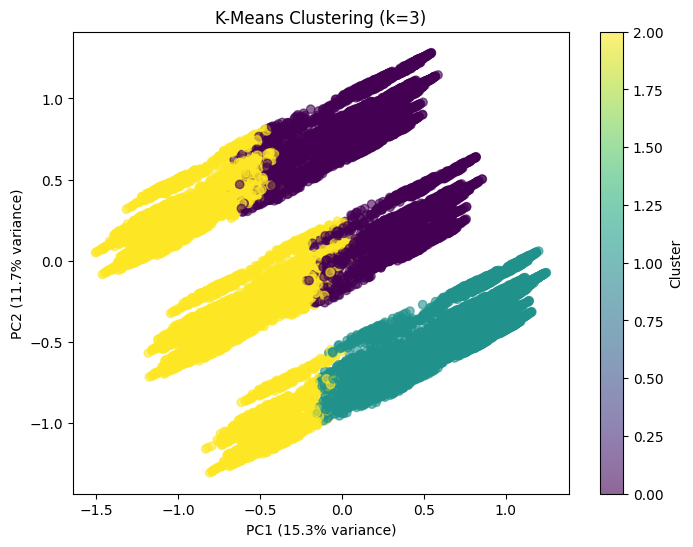

In [87]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering (k=3)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(label='Cluster')
plt.show()

In [88]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

sil_kmeans = silhouette_score(df, clusters_kmeans)
ch_kmeans = calinski_harabasz_score(df, clusters_kmeans)
db_kmeans = davies_bouldin_score(df, clusters_kmeans)

print(f"Silhouette Score: {sil_kmeans:.3f}")
print(f"Calinski-Harabasz: {ch_kmeans:.1f}")
print(f"Davies-Bouldin: {db_kmeans:.3f}")

Silhouette Score: 0.114
Calinski-Harabasz: 3389.7
Davies-Bouldin: 2.494


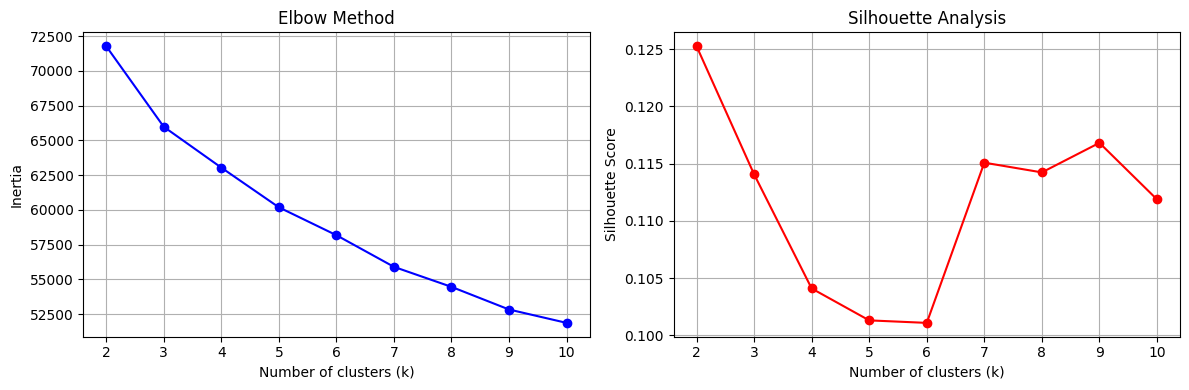

In [85]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(df, labels))

# График "локтя"
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Теперь попробуем с оптимальным значением по силуету
Излом локтевой у нас примерно около 3. Силует же показывает хорошие показатели у 2, следовательно 2 будет славным решением

In [94]:
optimal_k = 2 # например
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42)

clusters_kmeans_opt = kmeans_opt.fit_predict(df)

df_not_processed['cluster_kmeans_opt'] = clusters_kmeans_opt
df_not_processed['cluster_kmeans_opt'].value_counts().sort_index()

cluster_kmeans_opt
0    16220
1    11681
Name: count, dtype: int64

In [95]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

sil_kmeans = silhouette_score(df, clusters_kmeans_opt)
ch_kmeans = calinski_harabasz_score(df, clusters_kmeans_opt)
db_kmeans = davies_bouldin_score(df, clusters_kmeans_opt)

print(f"Silhouette Score: {sil_kmeans:.3f}")
print(f"Calinski-Harabasz: {ch_kmeans:.1f}")
print(f"Davies-Bouldin: {db_kmeans:.3f}")

Silhouette Score: 0.125
Calinski-Harabasz: 3980.2
Davies-Bouldin: 2.601


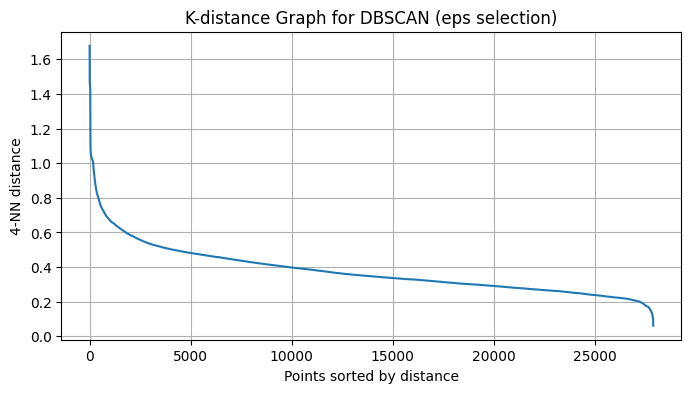

In [96]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

k = 4 
nbrs = NearestNeighbors(n_neighbors=k).fit(df)
distances, indices = nbrs.kneighbors(df)
distances = np.sort(distances[:, k-1], axis=0)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-NN distance')
plt.title('K-distance Graph for DBSCAN (eps selection)')
plt.grid(True)
plt.show()

Наблюдаем два излома. Слева - точки, которые далеко от соседей. Справа - точки очень близко, наверное, плотные кластеры

In [114]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.4, min_samples=9)
clusters_dbscan = dbscan.fit_predict(df)

df_not_processed['cluster_dbscan'] = clusters_dbscan
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"Найдено кластеров: {n_clusters}, шумовых точек: {n_noise}")

Найдено кластеров: 375, шумовых точек: 13727


In [116]:
mask = clusters_dbscan != -1
if mask.sum() > 1:
    sil_dbscan = silhouette_score(df[mask], clusters_dbscan[mask])
else:
    sil_dbscan = -1  # нельзя посчитать

print(f"Silhouette (без шума): {sil_dbscan:.3f}")

Silhouette (без шума): 0.472


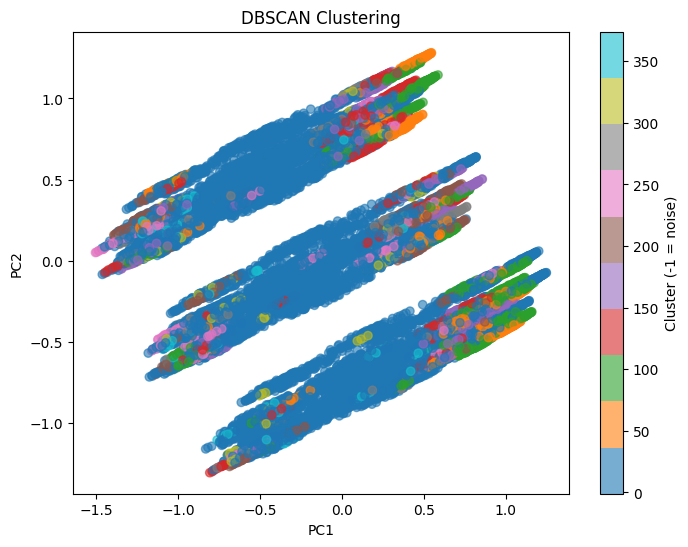

In [115]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_dbscan, cmap='tab10', alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.show()